# 18 — LiDAR-only versus LiDAR–camera fusion

This notebook compares the two detectors under the same decoder settings. On the labeled validation split it reports center-based precision, recall, F1, and mean matched-center error. On KITTI testing it can only compare prediction behaviour and plots because KITTI test labels are not distributed. These diagnostics are not official KITTI Average Precision.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CURRENT_DIRECTORY = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIRECTORY if (CURRENT_DIRECTORY / 'src').is_dir() else CURRENT_DIRECTORY.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset.kitti_dataset import KittiDataset
from src.geometry.boxes import box_corners_from_parameters
from src.geometry.transforms import lidar_xy_to_bev
from src.inference.pipeline import (
    evaluate_dataset, infer_dataset, infer_sample,
    load_detector_checkpoint, summarize_predictions,
)

## Configuration

`VALIDATION_LIMIT=None` evaluates every held-out frame. Test inference is deliberately capped initially because running both models over all 7,518 test frames can take a long time. Change `TEST_LIMIT` to `None` for the final full-test milestone. Keep the threshold fixed between models for a controlled comparison.

In [ ]:
LIDAR_CHECKPOINT = PROJECT_ROOT / 'outputs' / 'bev_detector_multiscale_full.pth'
FUSION_CHECKPOINT = PROJECT_ROOT / 'outputs' / 'bev_detector_fusion_full_seed42.pth'
SCORE_THRESHOLD = 0.30
TOP_K = 50
MIN_CENTER_DISTANCE = 1.5
MATCH_DISTANCE = 2.0
VALIDATION_LIMIT = None
TEST_LIMIT = 200  # Set to None to process all 7,518 KITTI testing frames.

In [ ]:
lidar_model, lidar_checkpoint, device = load_detector_checkpoint(LIDAR_CHECKPOINT)
fusion_model, fusion_checkpoint, fusion_device = load_detector_checkpoint(
    FUSION_CHECKPOINT, device=device
)
assert lidar_checkpoint['config']['input_mode'] == 'lidar'
assert fusion_checkpoint['config']['input_mode'] == 'fusion'
lidar_validation = lidar_checkpoint['split']['validation_indices']
fusion_validation = fusion_checkpoint['split']['validation_indices']
shared_validation = sorted(set(lidar_validation).intersection(fusion_validation))
if not shared_validation:
    raise ValueError('The checkpoints have no shared held-out validation frames.')
validation_indices = shared_validation[:VALIDATION_LIMIT]
print('Device:', device)
print('LiDAR validation frames:', len(lidar_validation))
print('Fusion validation frames:', len(fusion_validation))
print('Shared frames unseen by both:', len(validation_indices))
print('LiDAR seed:', lidar_checkpoint['config'].get('seed'))
print('Fusion seed:', fusion_checkpoint['config'].get('seed'))

Device: cuda
LiDAR validation frames: 1496
Fusion validation frames: 1496
Shared frames unseen by both: 293
LiDAR seed: 0
Fusion seed: 42


## Held-out validation comparison

In [ ]:
validation_dataset = KittiDataset(
    PROJECT_ROOT / 'data' / 'KITTI', split='training', load_images=True
)
evaluation_options = dict(
    device=device, score_threshold=SCORE_THRESHOLD, top_k=TOP_K,
    min_center_distance=MIN_CENTER_DISTANCE, match_distance=MATCH_DISTANCE,
)
lidar_metrics, lidar_validation_records = evaluate_dataset(
    lidar_model, validation_dataset, validation_indices, 'lidar', **evaluation_options
)
fusion_metrics, fusion_validation_records = evaluate_dataset(
    fusion_model, validation_dataset, validation_indices, 'fusion', **evaluation_options
)

In [ ]:
def print_metrics(name, metrics):
    print(f'{name:12s} | precision {metrics["precision"]:.3f} | '
          f'recall {metrics["recall"]:.3f} | F1 {metrics["f1"]:.3f} | '
          f'mean center error {metrics["mean_center_error"]:.3f} m | '
          f'TP/FP/FN {metrics["true_positives"]}/'
          f'{metrics["false_positives"]}/{metrics["false_negatives"]}')

print_metrics('LiDAR', lidar_metrics)
print_metrics('Fusion', fusion_metrics)

LiDAR        | precision 0.812 | recall 0.818 | F1 0.815 | mean center error 0.154 m | TP/FP/FN 947/219/211
Fusion       | precision 0.873 | recall 0.898 | F1 0.885 | mean center error 0.129 m | TP/FP/FN 1040/151/118


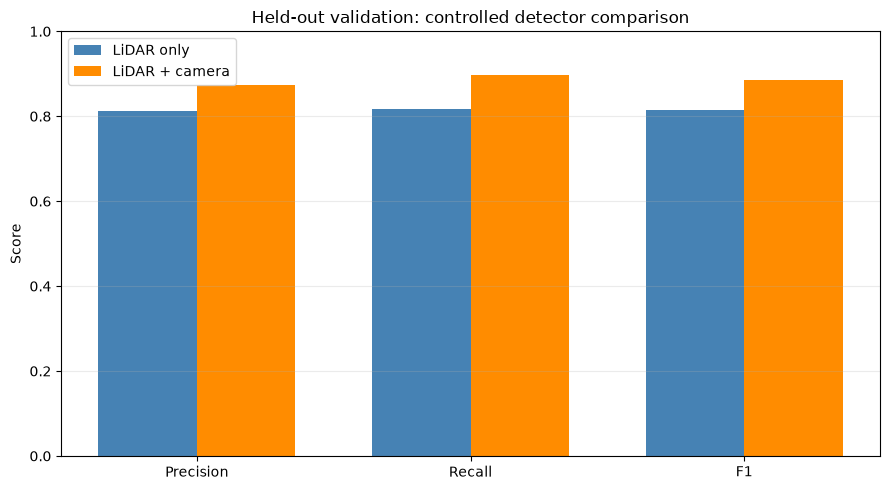

In [ ]:
names = ['Precision', 'Recall', 'F1']
lidar_values = [lidar_metrics[key] for key in ('precision', 'recall', 'f1')]
fusion_values = [fusion_metrics[key] for key in ('precision', 'recall', 'f1')]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.18, lidar_values, 0.36, label='LiDAR only', color='steelblue')
ax.bar(x + 0.18, fusion_values, 0.36, label='LiDAR + camera', color='darkorange')
ax.set_xticks(x, names)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Held-out validation: controlled detector comparison')
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## Confidence-threshold sweep

This experiment evaluates both models on the same shared validation frames at thresholds from 0.10 to 0.60. Lower thresholds usually increase recall; higher thresholds usually increase precision. This straightforward version reruns both models for every threshold and will take longer than the single-threshold comparison.


In [ ]:
THRESHOLDS = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
sweep_results = []

for threshold in THRESHOLDS:
    threshold_options = dict(
        device=device,
        score_threshold=threshold,
        top_k=TOP_K,
        min_center_distance=MIN_CENTER_DISTANCE,
        match_distance=MATCH_DISTANCE,
    )
    lidar_threshold_metrics, _ = evaluate_dataset(
        lidar_model, validation_dataset, validation_indices, 'lidar',
        **threshold_options,
    )
    fusion_threshold_metrics, _ = evaluate_dataset(
        fusion_model, validation_dataset, validation_indices, 'fusion',
        **threshold_options,
    )
    sweep_results.append({
        'threshold': threshold,
        'lidar': lidar_threshold_metrics,
        'fusion': fusion_threshold_metrics,
    })
    print(
        f"threshold {threshold:.2f} | "
        f"LiDAR P={lidar_threshold_metrics['precision']:.3f}, "
        f"R={lidar_threshold_metrics['recall']:.3f}, "
        f"F1={lidar_threshold_metrics['f1']:.3f} | "
        f"Fusion P={fusion_threshold_metrics['precision']:.3f}, "
        f"R={fusion_threshold_metrics['recall']:.3f}, "
        f"F1={fusion_threshold_metrics['f1']:.3f}"
    )


In [ ]:
metric_specifications = [
    ('precision', 'Precision'),
    ('recall', 'Recall'),
    ('f1', 'F1 score'),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)

for ax, (metric_key, title) in zip(axes, metric_specifications):
    lidar_values = [result['lidar'][metric_key] for result in sweep_results]
    fusion_values = [result['fusion'][metric_key] for result in sweep_results]
    ax.plot(THRESHOLDS, lidar_values, marker='o', label='LiDAR only')
    ax.plot(THRESHOLDS, fusion_values, marker='o', label='LiDAR + camera')
    ax.set_title(title)
    ax.set_xlabel('Confidence threshold')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Metric value')
axes[-1].legend()
fig.suptitle('Shared validation performance across confidence thresholds')
fig.tight_layout()
plt.show()

best_lidar = max(sweep_results, key=lambda result: result['lidar']['f1'])
best_fusion = max(sweep_results, key=lambda result: result['fusion']['f1'])
print(
    f"Best LiDAR threshold: {best_lidar['threshold']:.2f} "
    f"(F1={best_lidar['lidar']['f1']:.3f})"
)
print(
    f"Best fusion threshold: {best_fusion['threshold']:.2f} "
    f"(F1={best_fusion['fusion']['f1']:.3f})"
)


## Visual comparison on one validation frame

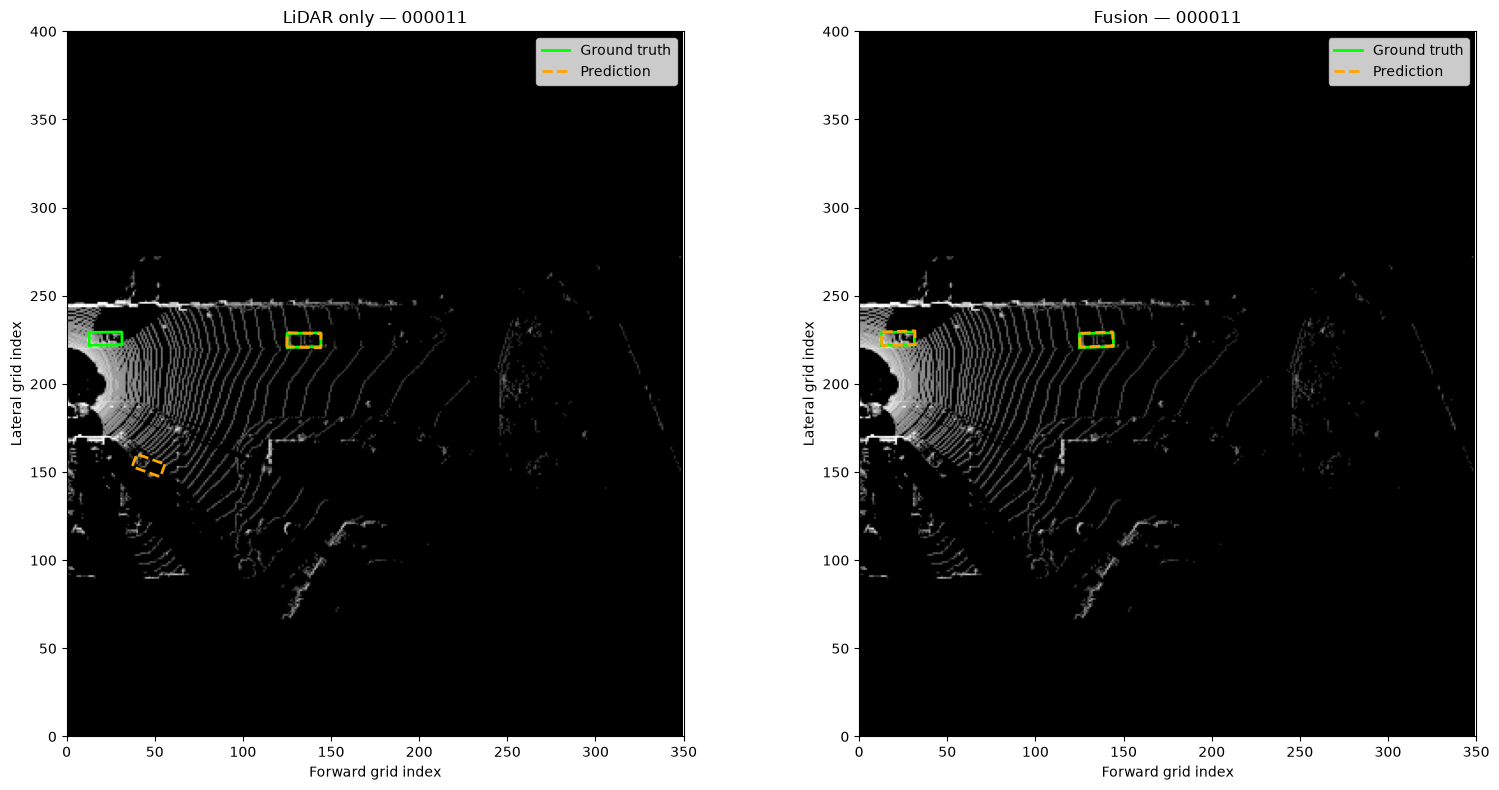

In [ ]:
def draw_box(ax, box, color, linestyle='-', label=None):
    corners = box_corners_from_parameters(
        box['center_x'], box['center_y'], box['length'], box['width'], box['yaw']
    )
    corners = lidar_xy_to_bev(corners)
    closed = np.vstack([corners, corners[0]])
    ax.plot(closed[:, 0], closed[:, 1], color=color, linestyle=linestyle,
            linewidth=2, label=label)

def plot_result(ax, result, title, show_ground_truth=True):
    ax.imshow(result['bev'][1].T, origin='lower', cmap='gray', aspect='equal')
    if show_ground_truth:
        for i, box in enumerate(result.get('ground_truth', [])):
            draw_box(ax, box, 'lime', '-', 'Ground truth' if i == 0 else None)
    for i, box in enumerate(result['detections']):
        draw_box(ax, box, 'orange', '--', 'Prediction' if i == 0 else None)
    ax.set_xlim(0, result['bev'].shape[1])
    ax.set_ylim(0, result['bev'].shape[2])
    ax.set_title(title)
    ax.set_xlabel('Forward grid index')
    ax.set_ylabel('Lateral grid index')
    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc='upper right')

example_index = validation_indices[0]
sample = validation_dataset[example_index]
lidar_example = infer_sample(lidar_model, sample, 'lidar', device, SCORE_THRESHOLD,
                             TOP_K, MIN_CENTER_DISTANCE)
fusion_example = infer_sample(fusion_model, sample, 'fusion', device, SCORE_THRESHOLD,
                              TOP_K, MIN_CENTER_DISTANCE)
ground_truth = lidar_validation_records[0]['ground_truth']
lidar_example['ground_truth'] = ground_truth
fusion_example['ground_truth'] = ground_truth
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_result(axes[0], lidar_example, f"LiDAR only — {sample['id']}")
plot_result(axes[1], fusion_example, f"Fusion — {sample['id']}")
fig.tight_layout()
plt.show()

## KITTI testing comparison (unlabeled)

The official testing folder contains no labels, so precision, recall, F1, and accuracy cannot be computed locally. The following comparison reports how often each model predicts and its score distribution. This is a behaviour check, not evidence that one model is more accurate.

In [ ]:
test_dataset = KittiDataset(
    PROJECT_ROOT / 'data' / 'KITTI', split='testing', load_images=True
)
test_indices = list(range(len(test_dataset)))
if TEST_LIMIT is not None:
    test_indices = test_indices[:TEST_LIMIT]
print(f'Running both models on {len(test_indices)} of {len(test_dataset)} test frames')
decode_options = dict(
    score_threshold=SCORE_THRESHOLD, top_k=TOP_K,
    min_center_distance=MIN_CENTER_DISTANCE,
)
lidar_test_records = infer_dataset(
    lidar_model, test_dataset, test_indices, 'lidar', device=device, **decode_options
)
fusion_test_records = infer_dataset(
    fusion_model, test_dataset, test_indices, 'fusion', device=device, **decode_options
)
lidar_test_summary = summarize_predictions(lidar_test_records)
fusion_test_summary = summarize_predictions(fusion_test_records)
print('LiDAR test summary:', lidar_test_summary)
print('Fusion test summary:', fusion_test_summary)

Running both models on 200 of 7518 test frames
LiDAR test summary: {'samples': 200, 'total_detections': 625, 'frames_with_detections': 159, 'mean_detections_per_frame': 3.125, 'mean_score': 0.45399936723709106}
Fusion test summary: {'samples': 200, 'total_detections': 631, 'frames_with_detections': 153, 'mean_detections_per_frame': 3.155, 'mean_score': 0.5096432710222888}


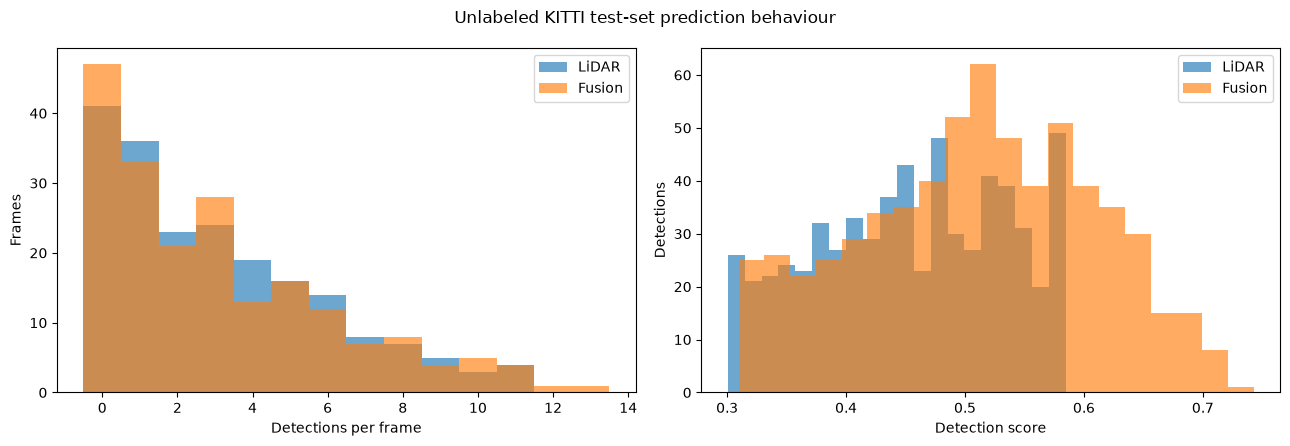

In [ ]:
lidar_counts = [len(record['detections']) for record in lidar_test_records]
fusion_counts = [len(record['detections']) for record in fusion_test_records]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.arange(0, max(lidar_counts + fusion_counts + [1]) + 2) - 0.5
axes[0].hist(lidar_counts, bins=bins, alpha=0.65, label='LiDAR')
axes[0].hist(fusion_counts, bins=bins, alpha=0.65, label='Fusion')
axes[0].set_xlabel('Detections per frame')
axes[0].set_ylabel('Frames')
axes[0].legend()
lidar_scores = [d['score'] for r in lidar_test_records for d in r['detections']]
fusion_scores = [d['score'] for r in fusion_test_records for d in r['detections']]
axes[1].hist(lidar_scores, bins=20, alpha=0.65, label='LiDAR')
axes[1].hist(fusion_scores, bins=20, alpha=0.65, label='Fusion')
axes[1].set_xlabel('Detection score')
axes[1].set_ylabel('Detections')
axes[1].legend()
fig.suptitle('Unlabeled KITTI test-set prediction behaviour')
fig.tight_layout()
plt.show()

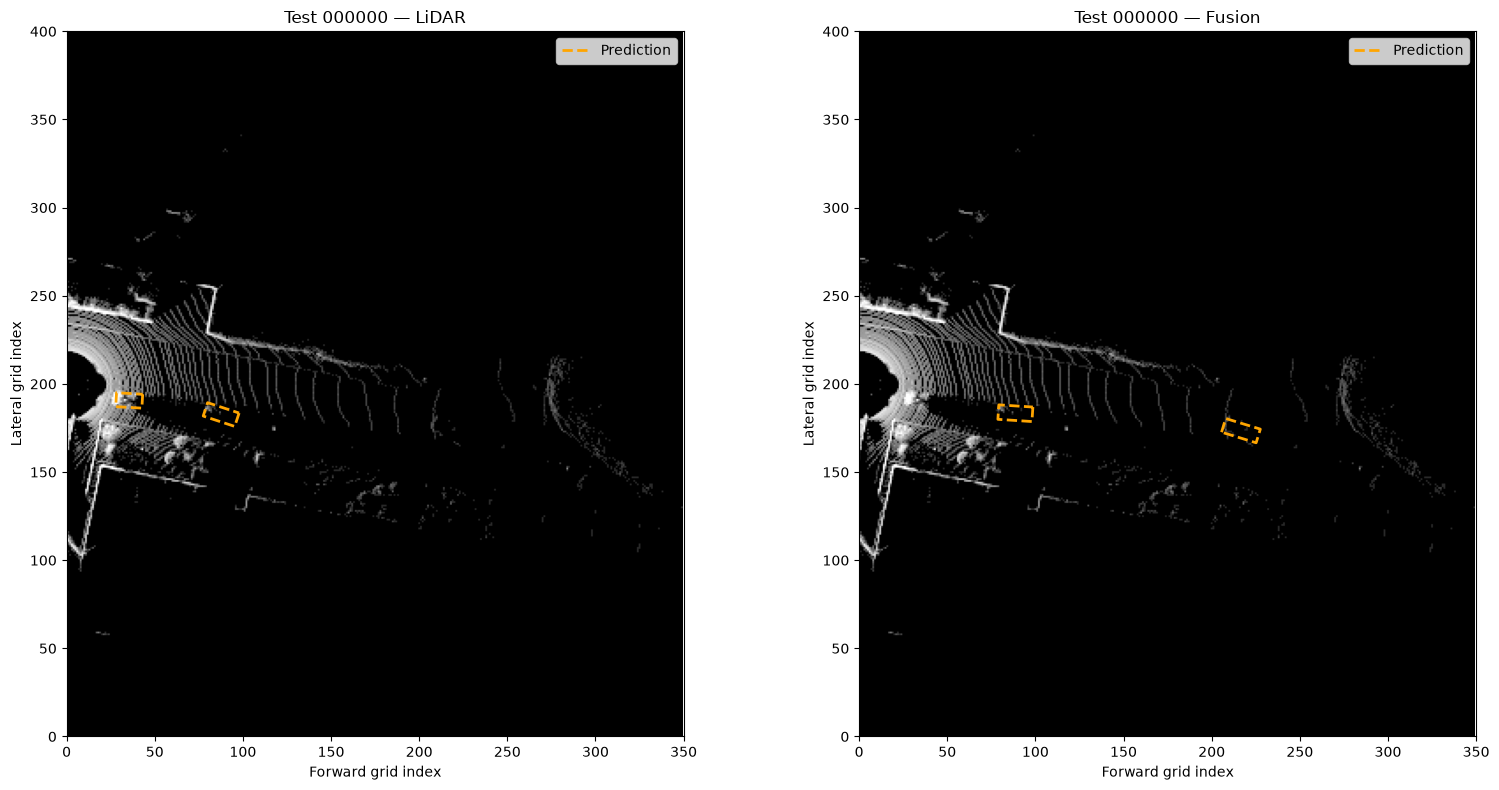

In [ ]:
test_example_index = test_indices[0]
test_sample = test_dataset[test_example_index]
lidar_test_example = infer_sample(
    lidar_model, test_sample, 'lidar', device=device, **decode_options
)
fusion_test_example = infer_sample(
    fusion_model, test_sample, 'fusion', device=device, **decode_options
)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_result(axes[0], lidar_test_example, f"Test {test_sample['id']} — LiDAR", False)
plot_result(axes[1], fusion_test_example, f"Test {test_sample['id']} — Fusion", False)
fig.tight_layout()
plt.show()

## How to interpret the experiment

The validation table is the meaningful local accuracy comparison. Fusion is better only if it improves the chosen validation metric while using exactly the same held-out frames and decoder settings. Test-set counts and confidence histograms can reveal unstable behaviour or a distribution shift, but without labels they cannot establish accuracy. For an official result, export KITTI-format detections and submit them to the KITTI evaluation server.